The CCA analysis I did earlier bombed. So instead of slogging my way through some AI slop, imma redo it with a test signal

In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import seaborn as sn

Parameter

In [6]:
srate = 256

s_time = 0
f_time = 4
times = np.linspace(s_time, f_time, (f_time - s_time) * srate)

(1024,)


Generating sample signals

(1024,)


Text(0, 0.5, 'Potential (microV)')

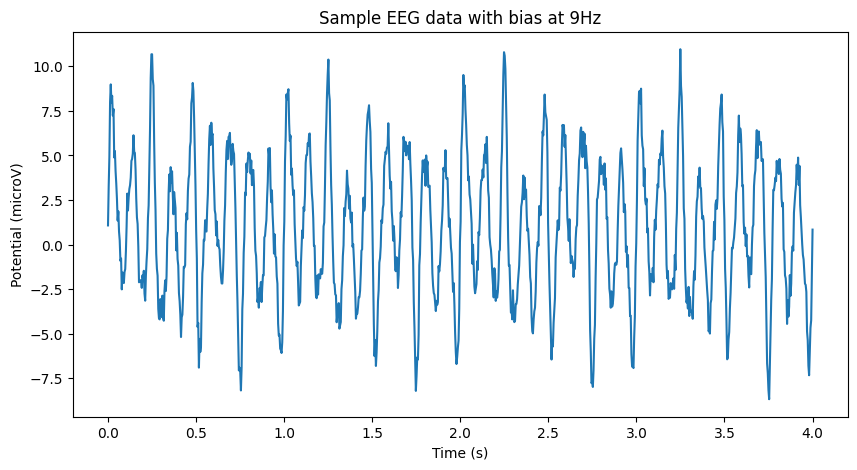

In [55]:
freq_to_sample = [2,5,9,13,17,21]
freq_weight = [1,1,5,1,1,1]
randWeight = 2

signal = np.zeros(len(times))
for (freq, weight) in zip(freq_to_sample, freq_weight):
    signal += weight * np.sin(2 * np.pi * freq * times)

signal += randWeight * np.random.rand(len(times))
print(np.shape(signal))

plt.figure(figsize=(10, 5))
plt.plot(times, signal)
plt.title("Sample EEG data with bias at 9Hz")
plt.xlabel("Time (s)")
plt.ylabel("Potential (microV)")

I shall now create a template reference signals

In [ ]:
#Reference Signals at 9Hz and 17Hz
freq_ref = [19]
reference_signal = np.zeros([len(freq_ref), len(times)])
for idx, freq in enumerate(freq_ref):
    reference_signal[idx] = np.sin(2 * np.pi * freq * times)
print(np.shape(reference_signal))

(1, 1024)


I will now create cross and auto covariance matrices and visualize them

In [123]:
#Y be the reference signals and X be the EEG signal
signal_centered = signal - np.mean(signal)

C_XX = np.array([[signal_centered @ signal_centered.T / len(times)]])
C_YY = reference_signal @ reference_signal.T / len(times)
C_XY = np.array([signal_centered @ reference_signal.T / len(times)])
C_YX = C_XY.T

In [124]:
print("Auto Covariance of EEG: ", C_XX)
print("Auto Covarince of reference signal: \n", C_YY)
print("Cross Covariance of both: ", C_XY)

Auto Covariance of EEG:  [[15.27232869]]
Auto Covarince of reference signal: 
 [[0.49951172]]
Cross Covariance of both:  [[-0.0048916]]


Computing Canonical Correlation Matrix A

In [125]:
A = np.linalg.pinv(C_XX) @ C_XY @ np.linalg.pinv(C_YY) @ C_YX
print(A)

[[3.13654675e-06]]
